In [2]:
from datasets import load_from_disk

dset = load_from_disk("/mnt/d/SoftWare/PycharmProjects/data/data_g3_z_1k/train_dataset")
dset.set_format("torch")
print(dset)

Dataset({
    features: ['image', 'spectrum', 'params', 'z'],
    num_rows: 1000
})


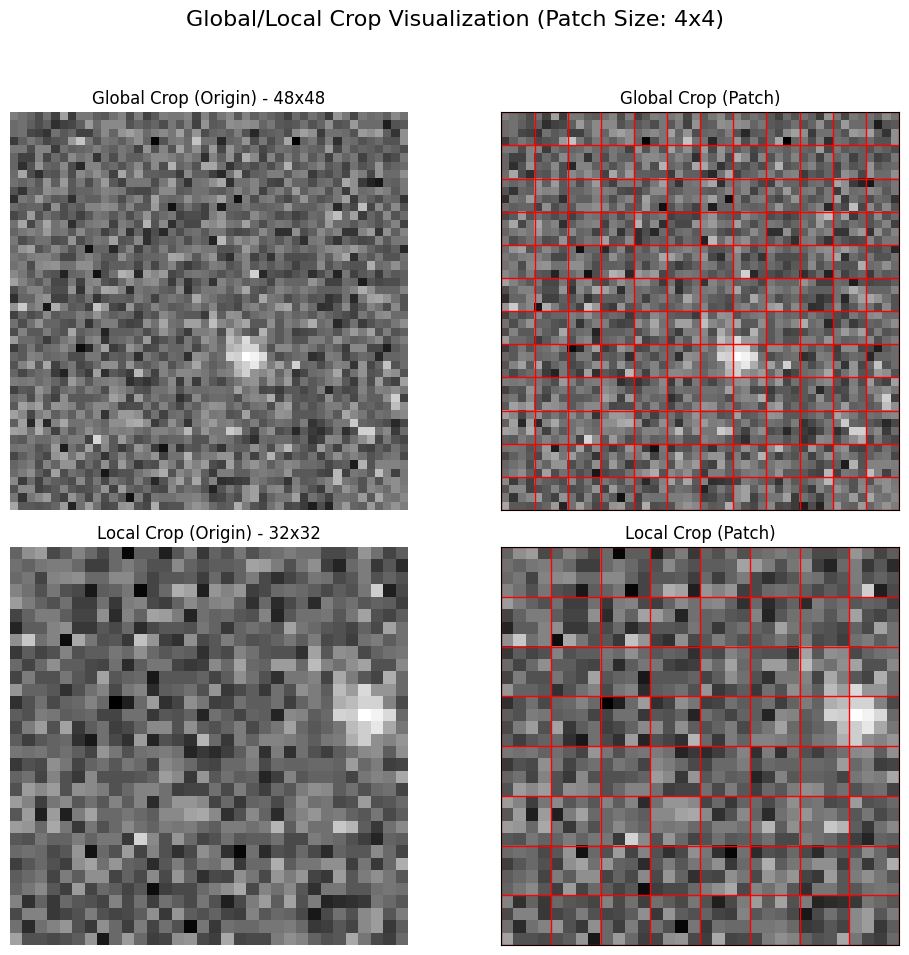

In [6]:
import torch
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from torchvision.transforms import v2 as T


def visualize_patching(image: torch.Tensor, patch_size: int = 8,
                       global_crops_size: int = 64, local_crops_size: int = 40):
    """
    将输入的5通道图片进行全局和局部裁剪，并可视化每个视图在patch前后的样子。

    Args:
        image (torch.Tensor):输入的图片张量，形状应为 (5, 64, 64)。
        patch_size (int, optional): Patch的大小。默认为 8。
        global_crops_size (int, optional): 全局视图的裁剪大小。默认为 64。
        local_crops_size (int, optional): 局部视图的裁剪大小。默认为 40。
    """
    # --- 输入验证 ---
    if not isinstance(image, torch.Tensor):
        raise TypeError("输入必须是 PyTorch Tensor 类型。")
    if image.dim() != 3 or image.shape != (5, 64, 64):
        raise ValueError("输入的 Tensor 形状必须为 (5, 64, 64)。")

    # --- 1. 选择中间通道进行操作 ---
    # 由于是5个通道，我们选择第3个通道（索引为2）
    middle_channel_image = image[2, :, :]

    # --- 2. 创建一个2x2的图表用于可视化 ---
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f'Global/Local Crop Visualization (Patch Size: {patch_size}x{patch_size})', fontsize=16)

    # --- 3. 处理和可视化全局视图 (Global View) ---
    # 裁剪为全局视图
    # 使用中心裁剪，确保即使尺寸不同也能得到一个确定的区域
    global_trans = T.RandomCrop(size=[global_crops_size, global_crops_size])
    global_view = global_trans(middle_channel_image.unsqueeze(0)).squeeze(0)

    # 可视化 patch 前的全局视图
    axs[0, 0].imshow(global_view.numpy(), cmap='gray')
    axs[0, 0].set_title(f'Global Crop (Origin) - {global_crops_size}x{global_crops_size}')
    axs[0, 0].axis('off')

    # 将全局视图划分为 patch
    # 使用 unfold 方法可以高效地提取不重叠的 patch
    # B, C, H, W -> B, C, num_patches_h, num_patches_w, patch_h, patch_w
    global_patches = global_view.unfold(0, patch_size, patch_size).unfold(1, patch_size, patch_size)

    # 将 patch 重新组合成一张图片以进行可视化
    num_patches_h = global_patches.shape[0]
    num_patches_w = global_patches.shape[1]
    global_view_patched = global_patches.contiguous().view(num_patches_h, num_patches_w, patch_size, patch_size)
    global_view_reconstructed = global_view_patched.permute(0, 2, 1, 3).reshape(global_crops_size, global_crops_size)

    # 可视化 patch 后的全局视图
    axs[0, 1].imshow(global_view_reconstructed.numpy(), cmap='gray')
    axs[0, 1].set_title(f'Global Crop (Patch)')
    # 添加网格线来清晰地展示 patch 的边界
    axs[0, 1].grid(which='both', color='red', linestyle='-', linewidth=1)
    axs[0, 1].set_xticks(torch.arange(-.5, global_crops_size, patch_size))
    axs[0, 1].set_yticks(torch.arange(-.5, global_crops_size, patch_size))
    axs[0, 1].set_xticklabels([])
    axs[0, 1].set_yticklabels([])
    axs[0, 1].tick_params(length=0)

    # --- 4. 处理和可视化局部视图 (Local View) ---
    # 为了可复现性，我们设置一个种子
    # torch.manual_seed(0)
    # 随机裁剪出局部视图
    # 我们需要先给图片增加一个 batch 维度，因为 torchvision 的变换通常需要 (B, C, H, W)
    transform = T.RandomCrop(size=[local_crops_size, local_crops_size])
    local_view = transform(middle_channel_image.unsqueeze(0)).squeeze(0)

    # 可视化 patch 前的局部视图
    axs[1, 0].imshow(local_view.numpy(), cmap='gray')
    axs[1, 0].set_title(f'Local Crop (Origin) - {local_crops_size}x{local_crops_size}')
    axs[1, 0].axis('off')

    # 将局部视图划分为 patch
    # 注意：如果裁剪尺寸不能被 patch 大小整除，unfold 会忽略掉右边和下边多余的像素
    local_patches = local_view.unfold(0, patch_size, patch_size).unfold(1, patch_size, patch_size)

    # 将 patch 重新组合成一张图片以进行可视化
    num_patches_h_local = local_patches.shape[0]
    num_patches_w_local = local_patches.shape[1]

    # 计算重建后的图像大小
    reconstructed_h = num_patches_h_local * patch_size
    reconstructed_w = num_patches_w_local * patch_size

    local_view_patched = local_patches.contiguous().view(num_patches_h_local, num_patches_w_local, patch_size,
                                                         patch_size)
    local_view_reconstructed = local_view_patched.permute(0, 2, 1, 3).reshape(reconstructed_h, reconstructed_w)

    # 可视化 patch 后的局部视图
    axs[1, 1].imshow(local_view_reconstructed.numpy(), cmap='gray')
    axs[1, 1].set_title(f'Local Crop (Patch)')
    # 添加网格线
    axs[1, 1].grid(which='both', color='red', linestyle='-', linewidth=1)
    axs[1, 1].set_xticks(torch.arange(-.5, reconstructed_w, patch_size))
    axs[1, 1].set_yticks(torch.arange(-.5, reconstructed_h, patch_size))
    axs[1, 1].set_xticklabels([])
    axs[1, 1].set_yticklabels([])
    axs[1, 1].tick_params(length=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# --- 使用示例 ---
if __name__ == '__main__':
    # 1. 创建一个符合要求的随机输入图片
    # 形状为 (5, 64, 64)
    img = dset[0]["image"]

    # 使用自定义参数

    visualize_patching(img, patch_size=4, global_crops_size=48, local_crops_size=32)

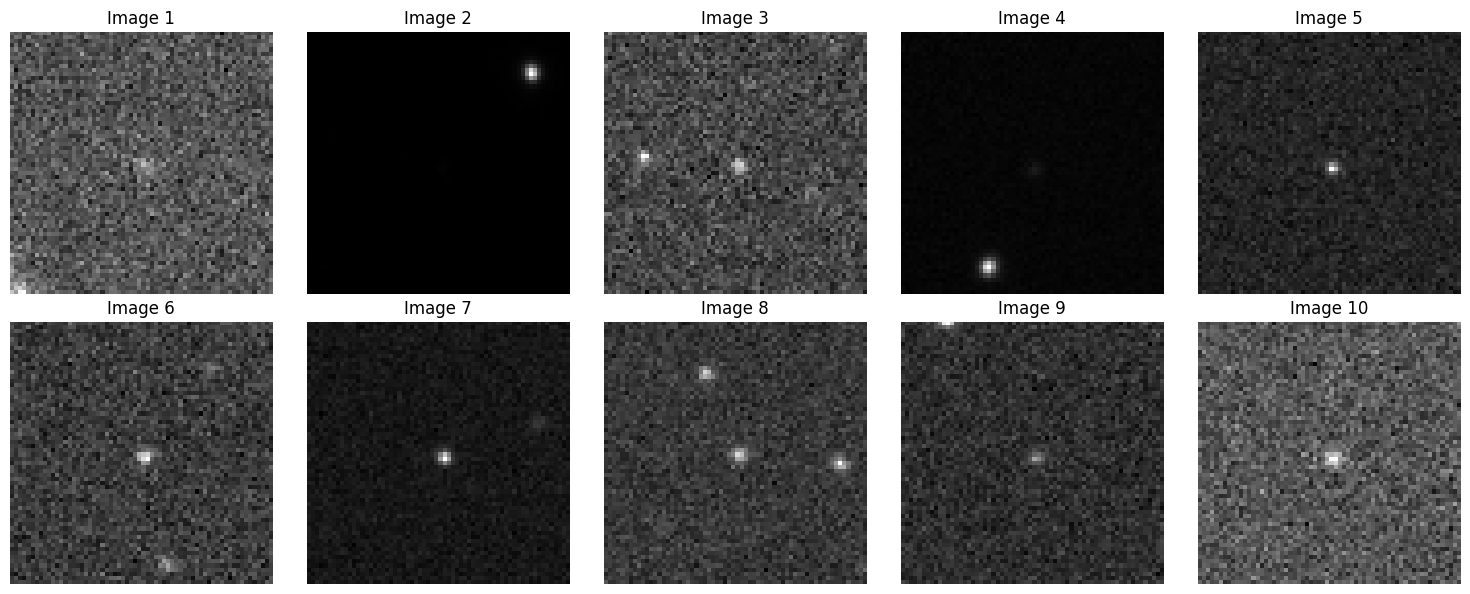

In [10]:

# print(dset)
from datasets import load_from_disk
import torch
import matplotlib.pyplot as plt

dset = load_from_disk("/mnt/d/SoftWare/PycharmProjects/data/data_g3_z_1k/train_dataset")
sampled_dset = dset.select(range(10))
imgs = [sampled_dset[i]["image"] for i in range(10)]
imgs = torch.stack(imgs)
# 假设 imgs 是一个形状为 [10, 5, 64, 64] 的 PyTorch 张量
# 选择最后一个通道（索引为4）
last_channel_imgs = imgs[:, 3, :, :]  # 形状变为 [10, 64, 64]

# 创建一个 2x5 的子图来显示所有图像
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()  # 将 axes 展平以便于迭代
for i in range(last_channel_imgs.shape[0]):
    ax = axes[i]
    img = last_channel_imgs[i].numpy()  # 转换为 NumPy 数组
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f'Image {i + 1}')

plt.tight_layout()
plt.show()

In [41]:
from datasets import load_from_disk
import torch
import numpy as np

dset = load_from_disk("/mnt/d/SoftWare/PycharmProjects/data/data_g3_z_1k/train_dataset")
imgs = np.array([i for i in dset['image']])

In [2]:
print(imgs.min(), imgs.max())

-1.2382812 496.5


(5, 64, 64)


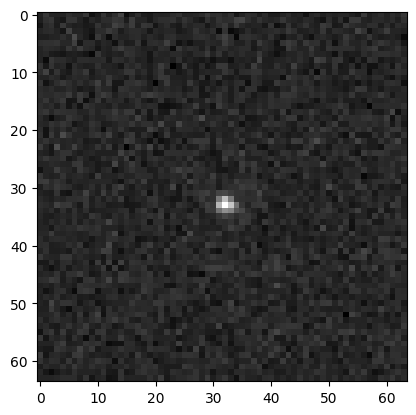

In [42]:
import matplotlib.pyplot as plt

img = imgs[4]
print(img.shape)
plt.imshow(img[1], cmap='gray')

In [14]:
from torchvision.transforms import transforms

global_crops_size = 64
local_crops_size = 40

trans_global = transforms.RandomResizedCrop(global_crops_size, scale=(0.8, 1.0),
                                            interpolation=transforms.InterpolationMode.BICUBIC)

# 对于 local crops
trans_local = transforms.RandomResizedCrop(local_crops_size, scale=(0.4, 0.6),
                                           interpolation=transforms.InterpolationMode.BICUBIC)

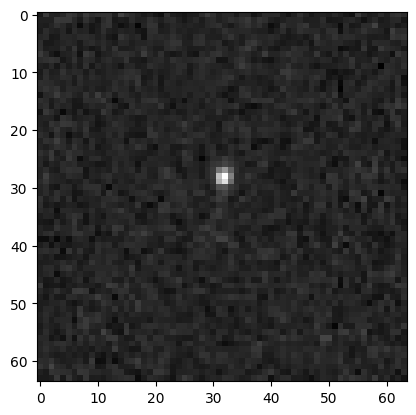

In [23]:
global_view = trans_global(torch.tensor(img))
plt.imshow(global_view[2].numpy(), cmap='gray')

/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


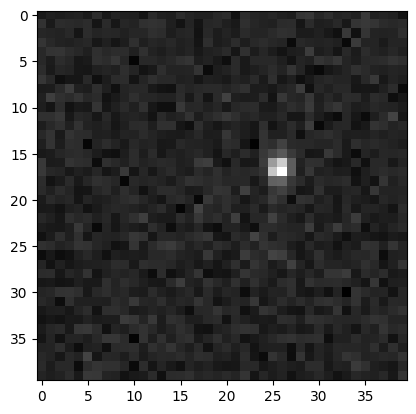

In [40]:
local_view = trans_local(torch.tensor(img))
plt.imshow(local_view[2].numpy(), cmap='gray')

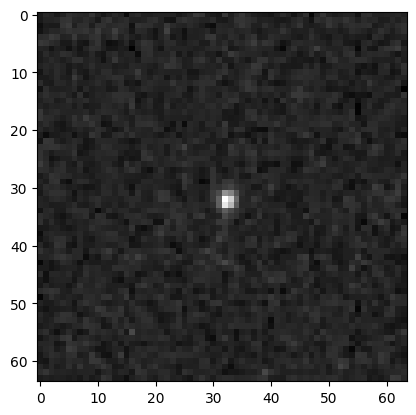

In [63]:
safe_crop_size_global = 56
global_crops_scale = (0.8, 1.0)
global_crops_size=64
trans = transforms.Compose([transforms.CenterCrop(safe_crop_size_global),
                            transforms.RandomResizedCrop(
                                global_crops_size,
                                scale=global_crops_scale,
                                interpolation=transforms.InterpolationMode.BICUBIC) ])
global_view = trans(torch.tensor(img))
plt.imshow(global_view[2].numpy(), cmap='gray')

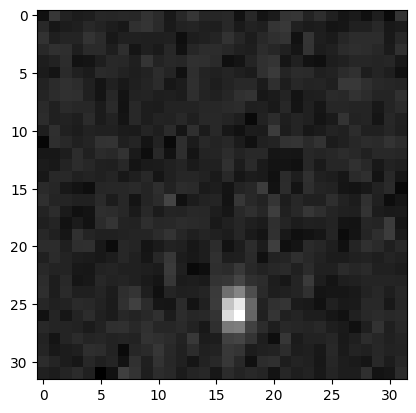

In [72]:
safe_crop_size_local = 48
local_crops_scale = (0.3, 0.7)
local_crops_size=32
trans = transforms.Compose([transforms.CenterCrop(safe_crop_size_local),
                            transforms.RandomResizedCrop(
                                local_crops_size,
                                scale=local_crops_scale,
                                interpolation=transforms.InterpolationMode.BICUBIC) ])
global_view = trans(torch.tensor(img))
plt.imshow(global_view[2].numpy(), cmap='gray')